# Logistic Regression with an invented example

**Data creation**

X.shape: (26, 2)


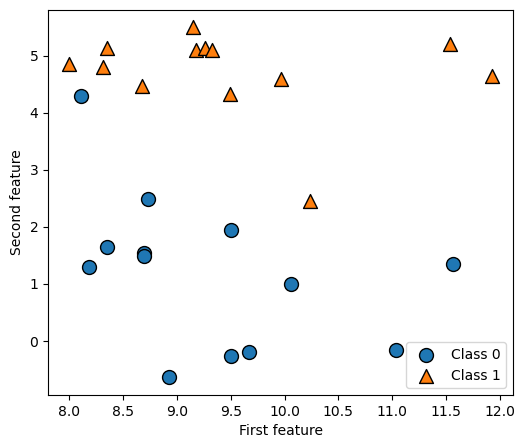

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.utils import check_random_state, shuffle

def make_blobs(centers=2, random_state=4, n_samples=30):
    g = check_random_state(random_state)

    # fixed setup (2 centers, 2 features, std=1)
    centers = g.uniform(-10, 10, size=(centers, centers))
    neg = int(n_samples/2)
    pos = n_samples-neg
    n = [neg, pos]  # 30 samples split evenly

    X = np.vstack([centers[i] + g.normal(scale=1.0, size=(n[i], 2)) for i in range(2)])
    y = np.array([i for i in range(2) for _ in range(n[i])])

    X, y = shuffle(X, y, random_state=g)
    return X, y

# a carefully hand-designed dataset 
def make_forge():
    X, y = make_blobs(centers=2, random_state=4, n_samples=30)
    y[np.array([7, 27])] = 0 # color two points blue 
    mask = np.ones(len(X), dtype=bool) # make a boolean array with all trues
    mask[np.array([0, 1, 5, 26])] = 0 # remove this
    X, y = X[mask], y[mask]
    return X, y

def plotScatter(X, y, figsize):
    plt.figure(figsize=figsize) 
    markers = ['o', '^']
    for i, class_value in enumerate(np.unique(y)):
        plt.scatter(
            X[y == class_value, 0],
            X[y == class_value, 1],
            marker=markers[i % len(markers)],
            s=100,                    # 👈 größere Punkte
            edgecolor='black',        # 👈 schwarzer Rand
            label=f"Class {class_value}"
        )

    plt.legend(loc=4)
    plt.xlabel("First feature")
    plt.ylabel("Second feature")
    return plt

X, y = make_forge()
ax = plotScatter(X, y, (6, 5))
print("X.shape:", X.shape)

**Perform Logistic Regression and visualize**

In [2]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression() # instantiation of the learning algorithm
clf.fit(X, y)              # train with all data

print(clf.intercept_)
print(clf.coef_)

[-11.09738878]
[[0.6728714  1.53137914]]


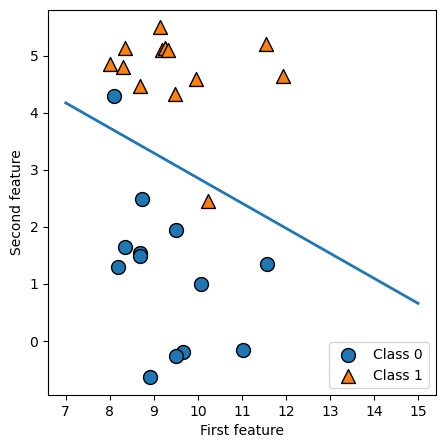

In [3]:
# Draw a decision boundary
def plotBoundary(clf, ax):
   th0 = clf.intercept_[0]
   th1, th2 = clf.coef_.T
   # Calculate the intercept and slope of the decision boundary.
   yintercept = -th0/th2
   slope = -th1/th2
   line_x = np.array([7,15]) # min and max x
   line_y = line_x*slope+yintercept
   ax.plot(line_x,line_y,linewidth=2)

ax = plotScatter(X, y, figsize=(5, 5))   # plot training points
plotBoundary(clf,ax)                     # plot boundary


**Making Predictions**<br>
Make some predictions with the already trained model *clf* according the following instructions
* Use the model to make a new prediction for the point $[9.5,1]$. 
* Vizualize the location of the examined data point in the plot. Please see https://matplotlib.org/3.5.0/api/_as_gen/matplotlib.axes.Axes.scatter.html
* In LinearRegression there is a function *predict_proba*. Call the function an try interpreting the values
* Find a second point very close to the line and compare the probabilities


In [ ]:
#plot training examples and decision boundary
ax = plotScatter(X,y, figsize=(5, 5))                                     # plot training points
plotBoundary(clf,ax)    

Xtest = np.array([[9.5, 1]])
ax.scatter(Xtest[:, 0], Xtest[:, 1], s=80, c='palegreen', edgecolor='black') # show the new point

print("Probability: ", clf.predict_proba(Xtest))
print("Prediction: ", clf.predict(Xtest))


In [ ]:
#plot training examples and decision boundary
ax = plotScatter(X,y, figsize=(5, 5))                                     # plot training points
plotBoundary(clf,ax)                                                      # plot decision boundary

#making predictions for first point
Xtest = np.array([[9.5, 1]])
pred = clf.predict(Xtest)
print('Prediction class:', pred)  
predprob = clf.predict_proba(Xtest);
print('Probabilities for each class:', predprob)
#plot training points and new test point
ax.scatter(Xtest[:, 0], Xtest[:, 1], s=80, c='palegreen', edgecolor='black') # show the new point



Xtest = np.array([[9.5, 3.15]])
ax.scatter(Xtest[:, 0], Xtest[:, 1], s=80, c='red', edgecolor='black') # show the new point
pred = clf.predict(Xtest)
print('Prediction class:', pred)  
predprob = clf.predict_proba(Xtest);
print('Probabilities for each class:', predprob)
#plot training points and new test point


### Try different Regularization Values

In [ ]:
#LogisticRegression?

In [ ]:
#Question: what effect would we expect on the coefficients

In [ ]:
from sklearn.linear_model import LogisticRegression

ax = plotScatter(X,y, figsize=(5, 5))                                     # plot training points

clf = LogisticRegression(C=0.5) # instantiation of the learning algorithm
clf.fit(X, y)              # train with all data
plotBoundary(clf,ax)    
print(clf.coef_)

clf = LogisticRegression(C=100) # instantiation of the learning algorithm
clf.fit(X, y)              # train with all data
plotBoundary(clf,ax) 
print(clf.coef_)